In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Load the data

In [7]:
df = pd.read_csv("C:Users/Acer/OneDrive/Desktop/Zara_Omnichannel_Retail_Dataset.csv")

In [9]:
print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully.
Shape of dataset: (1000, 15)

First 5 rows:
  Order_ID Customer_ID  Order_Date Product_ID Product_Name     Category  \
0   O00043       C0229  2025-01-01       P010   Sunglasses  Accessories   
1   O00073       C0259  2025-01-01       P005       Blazer    Outerwear   
2   O00316       C0041  2025-01-01       P007     Sneakers     Footwear   
3   O00935       C0043  2025-01-01       P010   Sunglasses  Accessories   
4   O00660       C0023  2025-01-02       P007     Sneakers     Footwear   

   Quantity  Unit_Price_INR  Sales_INR  Channel Region  Customer_Segment  \
0         1            1599    1439.10    Store   East  Regular Customer   
1         3            4999   12747.45  Website  North  Regular Customer   
2         1            3499    3149.10  Website   East  Premium Customer   
3         1            1599    1599.00    Store  South  Premium Customer   
4         1            3499    2974.15      App   East  Premium Customer   

  Payment_Method  D

#### Interpretation
- The data has 1,000 orders and 15 columns. Each row is one order with product, quantity, price, discount, channel, region, customer type, payment method and `Return_Flag`.
- `Return_Flag` (Yes/No) is the target, so this is a classification problem.



## Basic Information

In [10]:
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include="all").T)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Column Names:
['Order_ID', 'Customer_ID', 'Order_Date', 'Product_ID', 'Product_Name', 'Category', 'Quantity', 'Unit_Price_INR', 'Sales_INR', 'Channel', 'Region', 'Customer_Segment', 'Payment_Method', 'Discount_Percent', 'Return_Flag']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   object 
 1   Customer_ID       1000 non-null   object 
 2   Order_Date        1000 non-null   object 
 3   Product_ID        1000 non-null   object 
 4   Product_Name      1000 non-null   object 
 5   Category          1000 non-null   object 
 6   Quantity          1000 non-null   int64  
 7   Unit_Price_INR    1000 non-null   int64  
 8   Sales_INR         1000 non-null   float64
 9   Channel           1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Customer_Segment  10

#### Interpretation
- There are two variables categorical and numerical in the dataset
- 11 Categorical Variables- Order_ID, Customer_ID, Order_Date,
- Product_ID, Product_Name, Category, Channel, Region, Customer_Segment, Payment_Method, and Return_Flag.
- 4 Numerical Variables- Quantity, Unit_Price_INR, Sales_INR, and Discount_Percent
- No missing values and no duplicate rows, so the data is clean 
- Most orders have quantity 1 or 2, prices range from ₹799 to ₹4,999, and the average discount is about 8%.
- Average sales (₹4,248) is higher than the median (₹3,399), so a few large orders pull the average up. Only 83 of 1,000 orders are returned.

## Exploratory data analysis
### return distribution

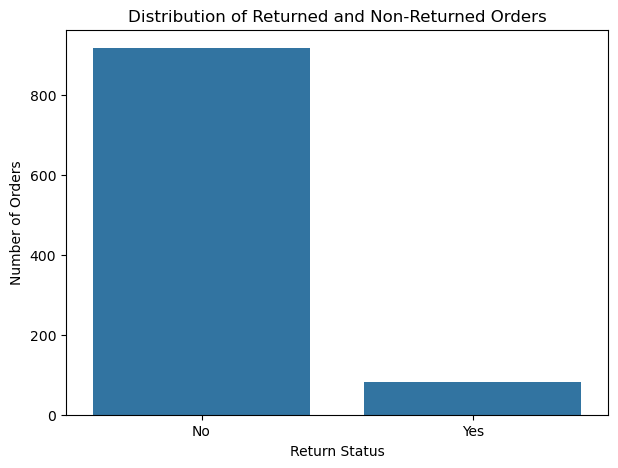

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Return_Flag")
plt.title("Distribution of Returned and Non-Returned Orders")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")
plt.show()

#### Interpretation
- About 91.7% of orders are not returned (917) and only 8.3% are returned (83), so the data is heavily imbalanced.
- Accuracy will be misleading, because always predicting "No" already scores about 92%. Recall, precision and ROC-AUC matter more.

### Sales Distribution

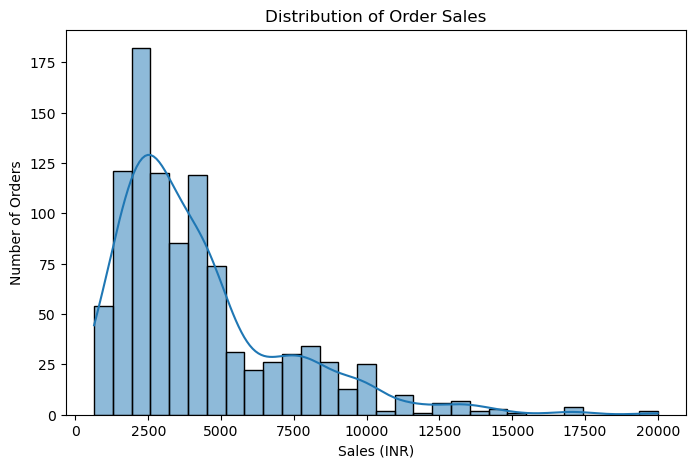

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales_INR"], bins=30, kde=True)
plt.title("Distribution of Order Sales")
plt.xlabel("Sales (INR)")
plt.ylabel("Number of Orders")
plt.show()

#### Interpretation
- Most orders are between roughly ₹600 and ₹5,000, with a long tail up to about ₹20,000, which is a right-skewed shape.
- The large orders are genuine (3 to 4 pieces of costly items), not errors, so they do not need removing.

###  Quantity vs Return

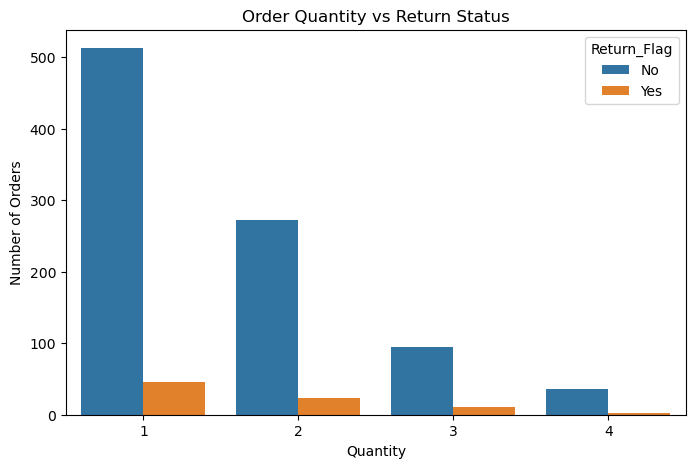

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Quantity", hue="Return_Flag")
plt.title("Order Quantity vs Return Status")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.show()

#### Interpretation
- Single-piece orders are the most common (56%), followed by 2 pieces (30%).
- Return rates are almost the same across quantities (about 8%, and 10% for quantity 3), so quantity does not explain returns.
- A return-rate chart would show this better than raw counts.

### Discount vs Return

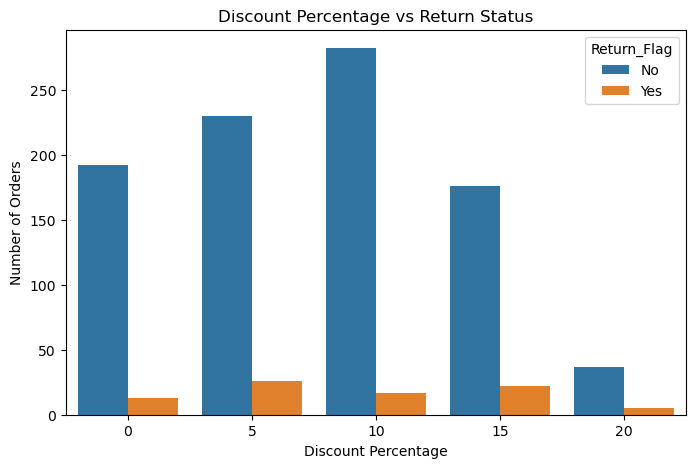

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Discount_Percent", hue="Return_Flag")
plt.title("Discount Percentage vs Return Status")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Orders")
plt.show()

#### Interpretation
- Most orders carry a 5% or 10% discount, and very few carry 20%.
- Return rates are 6.3% (0%), 10.2% (5%), 5.7% (10%), 11.1% (15%) and 11.9% (20%). Higher discounts look slightly worse, but the pattern is uneven and not statistically strong (p ≈ 0.10).

### Category vs Return

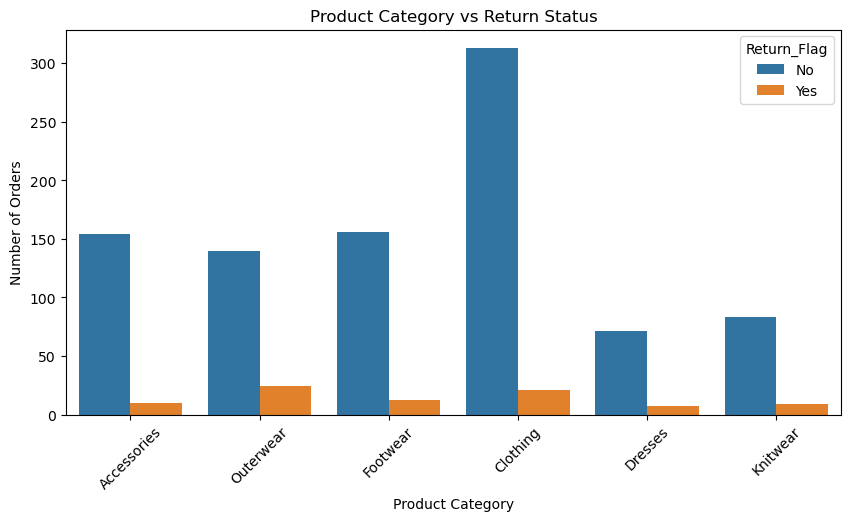

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Category",
    hue="Return_Flag"
)
plt.title("Product Category vs Return Status")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

#### Interpretation
- Clothing has the most orders (334), but Outerwear has the most returns (24 of 164).
- Outerwear's return rate of 14.6% is nearly double the overall 8.3%, while Accessories (6.1%) and Clothing (6.3%) are lowest.
- This is the only pattern that looks real (p ≈ 0.03), though with 83 returns the evidence is still modest.

### Channel vs Return

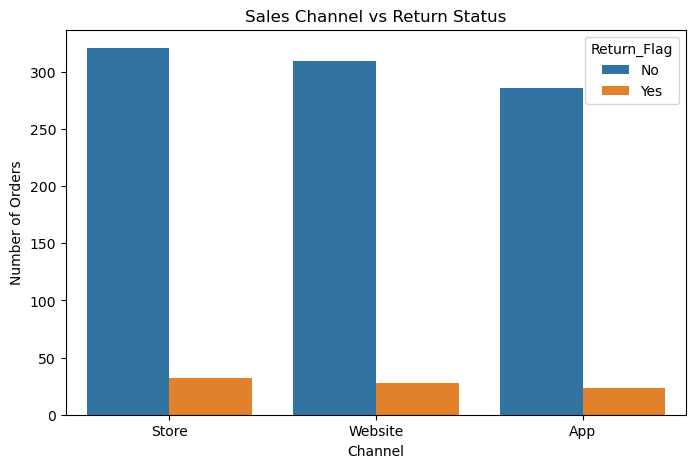

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Channel",
    hue="Return_Flag"
)
plt.title("Sales Channel vs Return Status")
plt.xlabel("Channel")
plt.ylabel("Number of Orders")
plt.show()

#### Interpretation
- Store, Website and App have similar order volumes and similar numbers of returns.
- Return rates are 9.1% (Store), 8.3% (Website) and 7.4% (App), a small gap that is not significant (p ≈ 0.75).

### Payment Method vs Return

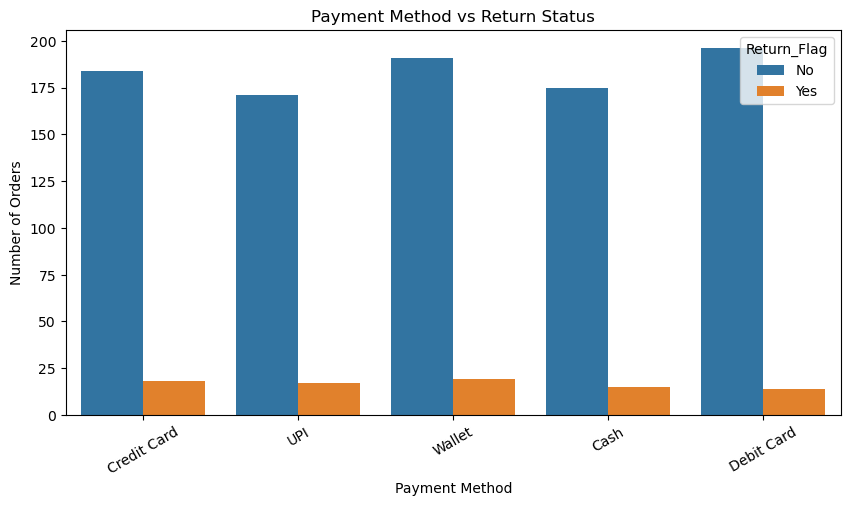

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Return_Flag"
)
plt.title("Payment Method vs Return Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

#### Interpretation
- Five payment methods are used, with Wallet the most common, and returns are spread evenly across them.
- No payment method stands out (p ≈ 0.88), so how a customer pays says nothing about returns.

###  Customer Segment vs Return

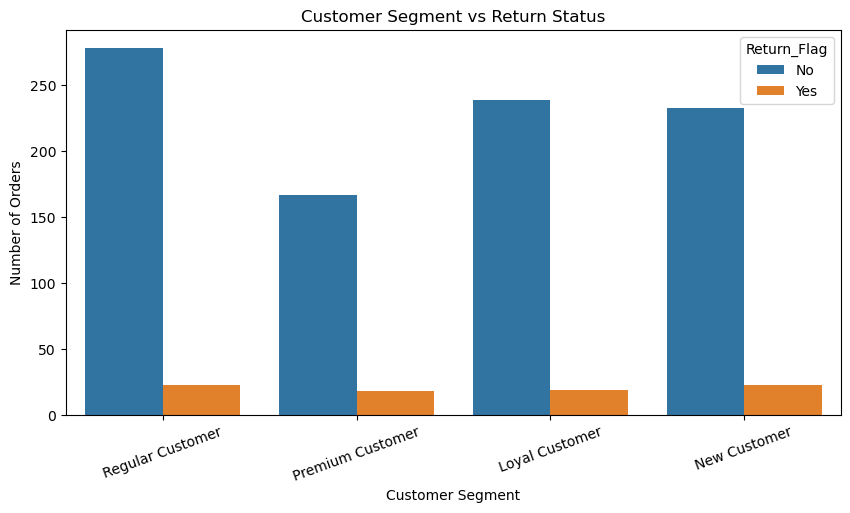

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Customer_Segment",
    hue="Return_Flag"
)
plt.title("Customer Segment vs Return Status")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

#### Interpretation
- Regular customers are the largest group (301 orders), with the other three segments close behind.
- Return rates are Premium 9.7%, New 9.0%, Regular 7.6% and Loyal 7.4%. New and Premium return slightly more, but the gap is small (p ≈ 0.77).

## CORRELATION ANALYSIS

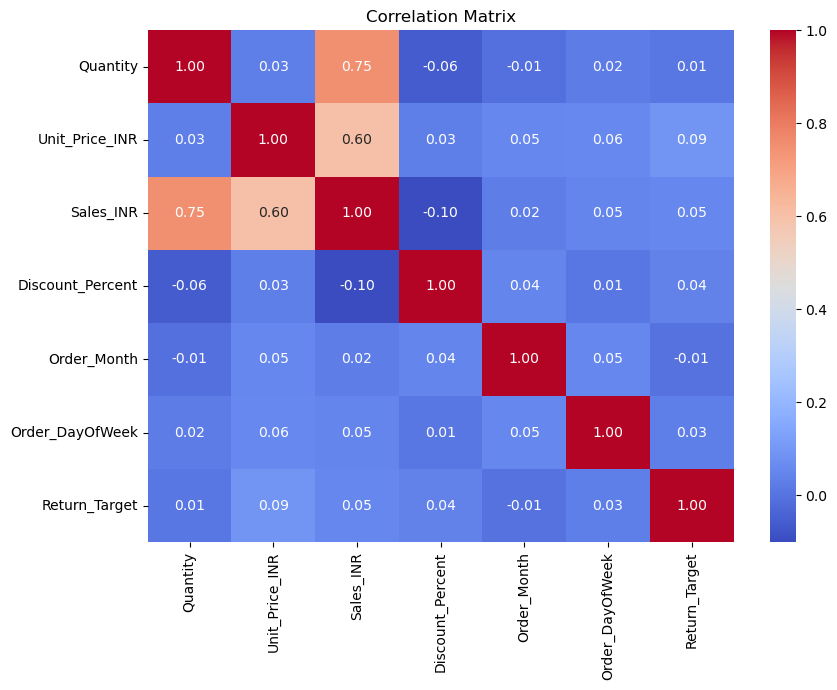

In [25]:
if "Return_Target" not in df.columns:
    df["Return_Target"] = df["Return_Flag"].map({
        "No": 0,
        "Yes": 1
    })

if "Order_Month" not in df.columns:
    df["Order_Month"] = pd.to_datetime(
        df["Order_Date"],
        errors="coerce"
    ).dt.month

if "Order_DayOfWeek" not in df.columns:
    df["Order_DayOfWeek"] = pd.to_datetime(
        df["Order_Date"],
        errors="coerce"
    ).dt.dayofweek


numeric_columns = [
    "Quantity",
    "Unit_Price_INR",
    "Sales_INR",
    "Discount_Percent",
    "Order_Month",
    "Order_DayOfWeek",
    "Return_Target"
]

# Keep only columns that actually exist
numeric_columns = [
    column for column in numeric_columns
    if column in df.columns
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Interpretation
- Sales is strongly related to Quantity (0.75) and Unit Price (0.60), because Sales = Quantity × Price × (1 − discount). It repeats information already in other columns.
- Every feature has a correlation near 0 with returns (price about 0.09, sales 0.05, discount 0.04, weekday 0.03, quantity 0.01, month −0.01).
- It warns that the models will struggle, and `Sales_INR` can be dropped for Logistic Regression.

## Return Distribution

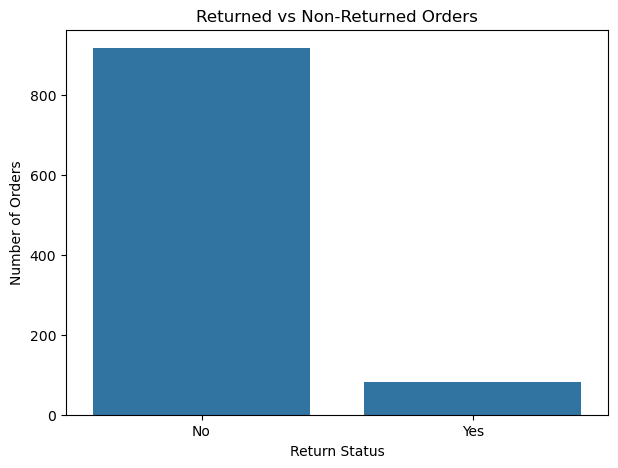

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Return_Flag"
)

plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")

plt.show()

## Sales Distribution

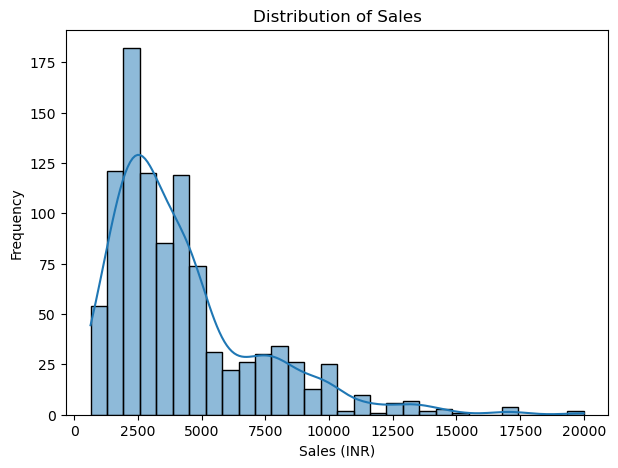

In [27]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="Sales_INR",
    bins=30,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales (INR)")
plt.ylabel("Frequency")

plt.show()


## Return Rate Analysis

In [28]:
print("RETURN RATE BY CATEGORY")

category_return = (
    df.groupby("Category")["Return_Target"]
    .mean()
    .sort_values(ascending=False)
)

display(category_return)


print("\nRETURN RATE BY CHANNEL")

channel_return = (
    df.groupby("Channel")["Return_Target"]
    .mean()
    .sort_values(ascending=False)
)

display(channel_return)


print("\nRETURN RATE BY CUSTOMER SEGMENT")

segment_return = (
    df.groupby("Customer_Segment")["Return_Target"]
    .mean()
    .sort_values(ascending=False)
)

display(segment_return)


print("\nRETURN RATE BY DISCOUNT")

discount_return = (
    df.groupby("Discount_Percent")["Return_Target"]
    .mean()
    .sort_values(ascending=False)
)

display(discount_return)


RETURN RATE BY CATEGORY


Category
Outerwear      0.146341
Knitwear       0.097826
Dresses        0.089744
Footwear       0.071429
Clothing       0.062874
Accessories    0.060976
Name: Return_Target, dtype: float64


RETURN RATE BY CHANNEL


Channel
Store      0.090652
Website    0.082840
App        0.074434
Name: Return_Target, dtype: float64


RETURN RATE BY CUSTOMER SEGMENT


Customer_Segment
Premium Customer    0.097297
New Customer        0.089844
Regular Customer    0.076412
Loyal Customer      0.073643
Name: Return_Target, dtype: float64


RETURN RATE BY DISCOUNT


Discount_Percent
20    0.119048
15    0.111111
5     0.101562
0     0.063415
10    0.056856
Name: Return_Target, dtype: float64

#### Interpretation
- Return rates are calculated for each group. This fixes the count-versus-rate problem in the charts, so it is the most useful part of the EDA.
- Outerwear (14.6%) is the only group clearly above the 8.3% average. Discount of 15–20% (about 11–12%) is mildly higher. Channel and customer segment differ by only a point or two.
- Adding the number of orders per group would help, since the 20% discount group has only 42 orders.

## Features

In [29]:
features = [
    "Quantity",
    "Unit_Price_INR",
    "Sales_INR",
    "Discount_Percent",
    "Order_Month",
    "Order_DayOfWeek",
    "Category",
    "Channel",
    "Region",
    "Customer_Segment",
    "Payment_Method"
]

X = df[features].copy()

y = df["Return_Target"].copy()

print("Features:")
print(features)

print("\nTarget:")
print("Return_Target")

Features:
['Quantity', 'Unit_Price_INR', 'Sales_INR', 'Discount_Percent', 'Order_Month', 'Order_DayOfWeek', 'Category', 'Channel', 'Region', 'Customer_Segment', 'Payment_Method']

Target:
Return_Target


#### Interpretation
- Eleven input columns are chosen and `Return_Target` is the answer. IDs, product name, date and the original `Return_Flag` are correctly left out.
- `Sales_INR` is redundant because it is calculated from three other columns.
- The assignment asks for a feature selection step, such as Random Forest importance, and it is missing here.

## Train/Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 11)
Testing data: (200, 11)


#### Interpretation
- 800 orders (80%) are used for training and 200 (20%) for testing. `stratify=y` keeps the return share the same in both, and `random_state=42` makes the result repeatable.
- Only about 17 returned orders land in the test set, so scores swing a lot by chance, and cross-validation would be more reliable.

In [ ]:
## Preprocessing

In [31]:
numeric_features = [
    "Quantity",
    "Unit_Price_INR",
    "Sales_INR",
    "Discount_Percent",
    "Order_Month",
    "Order_DayOfWeek"
]

categorical_features = [
    "Category",
    "Channel",
    "Region",
    "Customer_Segment",
    "Payment_Method"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing completed.")

Preprocessing completed.


#### Interpretation
- Number columns get missing values filled with the median and are scaled. Text columns get missing values filled with the most common value and are turned into 0/1 columns.

## Creation of the models(Ml)

In [32]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("4 ML models created successfully.")

4 ML models created successfully.


#### Interpretation
- Logistic Regression draws a dividing line, a Decision Tree asks yes/no questions, Random Forest lets 300 trees vote, and Gradient Boosting builds trees that fix each other's mistakes.
- `class_weight="balanced"` makes missed returns count more, but Gradient Boosting has no such setting here, so it ignores the imbalance.

## TRAIN AND COMPARE ALL ML MODELS

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
trained_models = {}

for model_name, model in models.items():

    print("Training:", model_name)

    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability of return
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    })

    # Store trained model
    trained_models[model_name] = pipeline


# Create results table
results_df = pd.DataFrame(results)

# Sort according to F1 Score
results_df = results_df.sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)
display(results_df)

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Decision Tree,0.355,0.088235,0.705882,0.156863,0.456284
1,Logistic Regression,0.605,0.044118,0.176471,0.070588,0.391835
2,Random Forest,0.905,0.000000,0.000000,0.000000,0.412086
3,Gradient Boosting,0.905,0.000000,0.000000,0.000000,0.412729


#### Interpretation
- Random Forest and Gradient Boosting show 90.5% accuracy but precision and recall of 0, so they predict almost no returns and are useless.
- All four models have ROC-AUC below 0.5 (0.39 to 0.46), which means they rank orders worse than random guessing. My 5-fold cross-validation gave about 0.47 for each, so this is not bad luck from one split.
- The models learned nothing useful from these features, even though the code itself runs properly.

In [41]:
results_df.to_csv(
    "ML_Model_Comparison.csv",
    index=False
)

print("ML_Model_Comparison.csv saved successfully.")

ML_Model_Comparison.csv saved successfully.


In [43]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]
print("BEST MODEL")
print(best_model_name)

BEST MODEL
Decision Tree


#### 🔎 Interpretation
- The Decision Tree is chosen because it has the highest F1 (0.157).
- That F1 equals the score of flagging every order as a return (precision 8.5%, recall 100%), so the tree is no better than a lazy rule. Its AUC is 0.456.
- The highest F1 here does not mean a good model, so the choice is not reliable.

In [46]:
from sklearn.metrics import classification_report

best_predictions = best_model.predict(X_test)

print("CLASSIFICATION REPORT")

report = classification_report(
    y_test,
    best_predictions,
    target_names=[
        "Not Returned",
        "Returned"
    ],
    zero_division=0
)

print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Returned       0.92      0.32      0.48       183
    Returned       0.09      0.71      0.16        17

    accuracy                           0.35       200
   macro avg       0.51      0.51      0.32       200
weighted avg       0.85      0.35      0.45       200



#### Interpretation
- For returned orders, precision is 0.09 and recall is 0.71. The model catches 12 of 17 returns, but only 9% of its return alerts are right.
- Accuracy is 0.35, far below the 0.92 you get by always predicting "No".
- In practice, staff would check about 136 orders to find 12 real returns.

## CONFUSION MATRIX

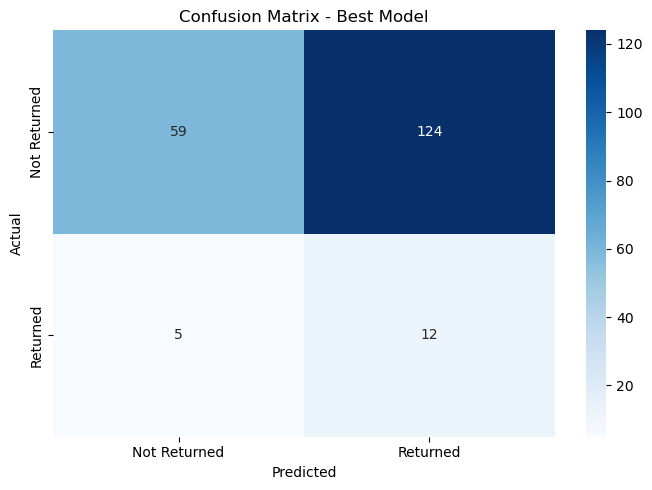

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Returned",
        "Returned"
    ],
    yticklabels=[
        "Not Returned",
        "Returned"
    ]
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#### Interpretation
- Of 183 non-returned orders, 124 are wrongly flagged as returns and only 59 are correct.
- Of 17 returned orders, 12 are caught and 5 are missed. Overall 71 of 200 predictions are right (35.5%).

## ROC CURVE

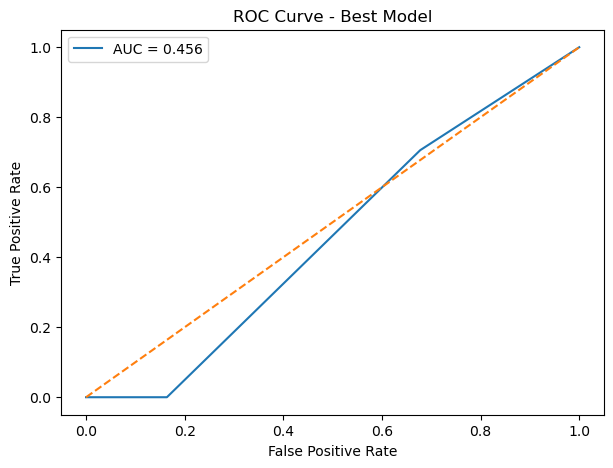

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

best_probability = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_probability
)

roc_auc = roc_auc_score(
    y_test,
    best_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="AUC = {:.3f}".format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()

plt.show()

#### Interpretation
- The dashed diagonal is a coin flip, and this curve sits on or below it with AUC = 0.456.
- The model cannot separate returned from non-returned orders. The curve has few corners because a depth-5 tree gives only a few distinct probabilities.
- The picture confirms there is no real predictive power.